In [1]:
from whisperx.vads.pyannote import load_vad_model

/home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [2]:
vad_pipeline = load_vad_model(
    device="cuda",
    token=os.environ["HF_TOKEN"]
)
wav_path = "/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav"
vad_scores = vad_pipeline("/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav")

Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.5. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../../../../../home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/whisperx/assets/pytorch_model.bin`
/home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(


In [4]:
vad_scores.data

array([[0.9572294 ],
       [0.95403504],
       [0.95560765],
       ...,
       [0.9006341 ],
       [0.8523569 ],
       [0.80083305]], shape=(31503, 1), dtype=float32)

In [3]:
scores = vad_scores.data[:, 0]
frames = vad_scores.sliding_window
times = [frames[i].middle for i in range(len(scores))]

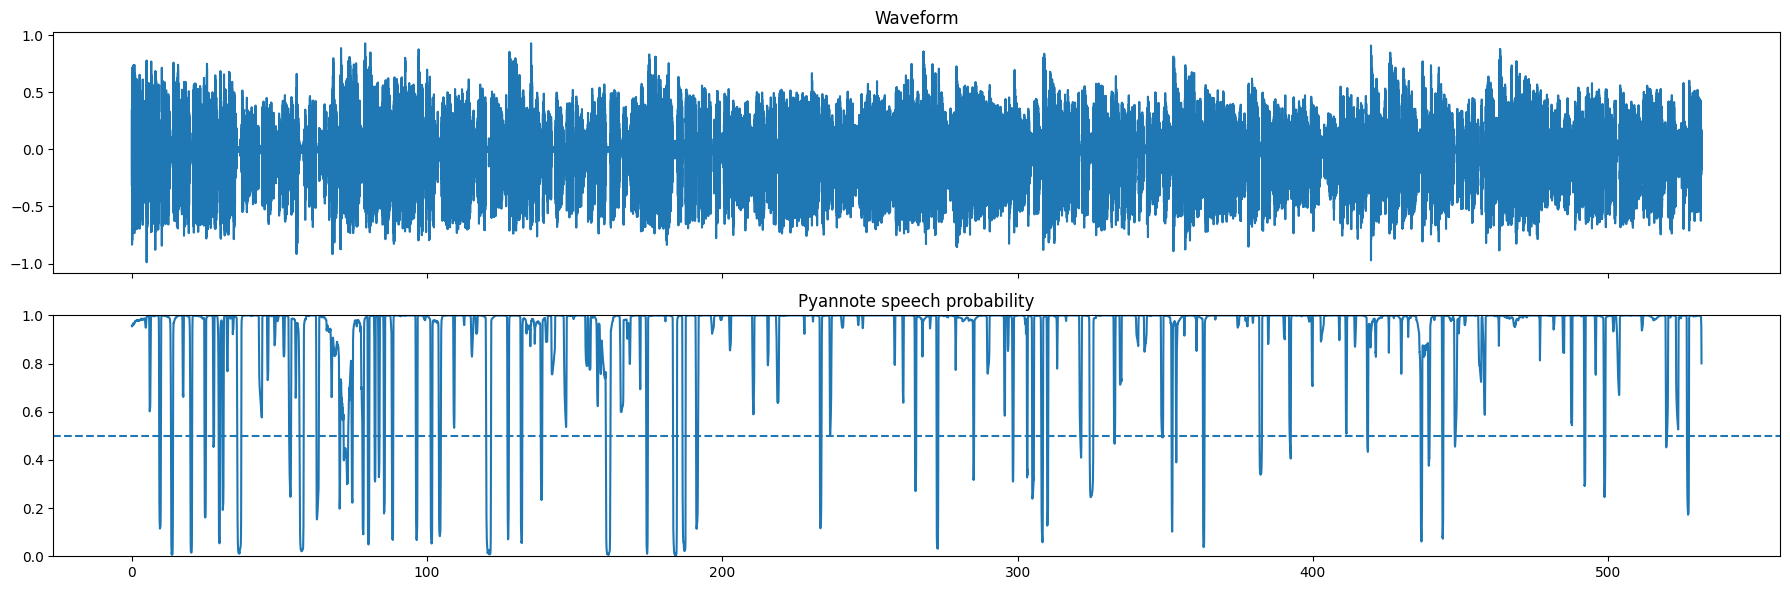

In [4]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

audio, sr = librosa.load("/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav", sr=16000)

audio_time = np.arange(len(audio)) / sr

scores = vad_scores.data[:, 0]
frames = vad_scores.sliding_window
vad_time = [frames[i].middle for i in range(len(scores))]

fig, ax = plt.subplots(
    2,
    1,
    figsize=(18, 6),
    sharex=True
)

# waveform
ax[0].plot(audio_time, audio)
ax[0].set_title("Waveform")

# VAD score
ax[1].plot(vad_time, scores)
ax[1].axhline(0.5, linestyle="--")
ax[1].set_ylim(0, 1)
ax[1].set_title("Pyannote speech probability")

plt.tight_layout()
plt.show()

In [5]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display


def inspect_chunk(
    wav_path,
    vad_scores,
    chunk,
    sr=16000,
):
    audio, sr = librosa.load(wav_path, sr=sr)

    # waveform time axis
    t_audio = np.arange(len(audio)) / sr

    # VAD scores
    scores = vad_scores.data[:, 0]
    frames = vad_scores.sliding_window
    t_vad = np.array(
        [frames[i].middle for i in range(len(scores))]
    )

    start = chunk["start"]
    end = chunk["end"]

    pad_start = chunk.get("pad_start", start)
    pad_end = chunk.get("pad_end", end)

    # zoom around chunk
    margin = 2.0

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(15, 5),
        sharex=True
    )

    # waveform
    ax[0].plot(t_audio, audio)

    ax[0].axvspan(
        start,
        end,
        alpha=0.3,
        label="speech chunk"
    )

    ax[0].axvline(start, linestyle="--")
    ax[0].axvline(end, linestyle="--")

    ax[0].axvline(pad_start, linestyle=":")
    ax[0].axvline(pad_end, linestyle=":")

    ax[0].set_title("Waveform")

    # vad probability
    ax[1].plot(t_vad, scores)

    ax[1].axvspan(
        start,
        end,
        alpha=0.3
    )

    ax[1].axvline(start, linestyle="--")
    ax[1].axvline(end, linestyle="--")

    ax[1].set_ylim(0, 1)
    ax[1].set_title("Pyannote VAD score")

    ax[1].set_xlim(
        max(0, start - margin),
        end + margin
    )

    plt.show()

    # play padded audio
    s0 = int(pad_start * sr)
    s1 = int(pad_end * sr)

    display(Audio(audio[s0:s1], rate=sr))

In [6]:
import numpy as np


def whisperx_chunking(
    vad_scores,
    chunk_size=30.0,
    onset=0.5,
    offset=0.363,
):
    """
    WhisperX-style VAD chunking.

    Parameters
    ----------
    vad_scores : SlidingWindowFeature
        Output of pyannote segmentation model.
    chunk_size : float
        Maximum chunk duration in seconds (typically 30s).
    onset : float
        VAD onset threshold.
    offset : float
        VAD offset threshold.

    Returns
    -------
    chunks : list[dict]
        [
            {
                "start": float,
                "end": float,
                "segments": [(s1,e1), (s2,e2), ...]
            }
        ]
    """

    frames = vad_scores.sliding_window
    scores = vad_scores.data[:, 0]

    timestamps = [frames[i].middle for i in range(len(scores))]

    # ---------------------------------------------------
    # STEP 1 : Binarization + Min-Cut
    # ---------------------------------------------------

    speech_segments = []

    is_active = scores[0] > onset
    start = timestamps[0]

    curr_scores = [scores[0]]
    curr_times = [timestamps[0]]

    for t, y in zip(timestamps[1:], scores[1:]):

        if is_active:

            duration = t - start

            # WhisperX min-cut
            if duration > chunk_size:

                search_after = len(curr_scores) // 2

                cut_idx = (
                    search_after
                    + np.argmin(curr_scores[search_after:])
                )

                cut_time = curr_times[cut_idx]

                speech_segments.append(
                    (start, cut_time)
                )

                start = cut_time

                curr_scores = curr_scores[cut_idx + 1 :]
                curr_times = curr_times[cut_idx + 1 :]

            elif y < offset:

                speech_segments.append(
                    (start, t)
                )

                is_active = False

                curr_scores = []
                curr_times = []

            curr_scores.append(y)
            curr_times.append(t)

        else:

            if y > onset:
                start = t
                is_active = True
                curr_scores = [y]
                curr_times = [t]

    if is_active:
        speech_segments.append((start, timestamps[-1]))

    # ---------------------------------------------------
    # STEP 2 : Merge
    # ---------------------------------------------------

    merged_chunks = []

    curr_start = speech_segments[0][0]
    curr_end = speech_segments[0][1]

    segs = [speech_segments[0]]

    for seg_start, seg_end in speech_segments[1:]:

        if seg_end - curr_start > chunk_size:

            merged_chunks.append(
                {
                    "start": curr_start,
                    "end": curr_end,
                    "segments": segs,
                }
            )

            curr_start = seg_start
            curr_end = seg_end
            segs = [(seg_start, seg_end)]

        else:

            curr_end = seg_end
            segs.append((seg_start, seg_end))

    merged_chunks.append(
        {
            "start": curr_start,
            "end": curr_end,
            "segments": segs,
        }
    )

    return merged_chunks

In [7]:
chunks = whisperx_chunking(
    vad_scores,
    chunk_size=30,
    onset=0.5,
    offset=0.363,
)

In [8]:
audio_duration = librosa.get_duration(path="/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav")

for chunk in chunks:
    chunk["pad_start"] = max(0, chunk["start"] - 0.5)
    chunk["pad_end"] = min(audio_duration, chunk["end"] + 0.5)
for i, chunk in enumerate(chunks):
    duration = chunk["end"] - chunk["start"]

    print(
        f"Chunk {i:03d}: "
        f"{chunk['start']:.2f}s -> "
        f"{chunk['end']:.2f}s "
        f"({duration:.2f}s)"
    )

Chunk 000: 0.03s -> 29.43s (29.40s)
Chunk 001: 29.90s -> 56.82s (26.92s)
Chunk 002: 58.22s -> 88.07s (29.85s)
Chunk 003: 88.54s -> 103.98s (15.44s)
Chunk 004: 104.69s -> 131.72s (27.03s)
Chunk 005: 132.25s -> 160.56s (28.32s)
Chunk 006: 162.10s -> 191.12s (29.02s)
Chunk 007: 191.78s -> 210.51s (18.73s)
Chunk 008: 210.51s -> 233.04s (22.53s)
Chunk 009: 233.58s -> 261.29s (27.71s)
Chunk 010: 261.29s -> 285.03s (23.74s)
Chunk 011: 285.25s -> 309.97s (24.72s)
Chunk 012: 310.38s -> 324.47s (14.09s)
Chunk 013: 325.63s -> 352.16s (26.53s)
Chunk 014: 352.52s -> 382.05s (29.53s)
Chunk 015: 382.77s -> 411.38s (28.60s)
Chunk 016: 411.38s -> 436.52s (25.14s)
Chunk 017: 437.03s -> 463.01s (25.99s)
Chunk 018: 463.01s -> 491.95s (28.94s)
Chunk 019: 492.27s -> 498.60s (6.33s)
Chunk 020: 499.08s -> 526.77s (27.69s)
Chunk 021: 527.37s -> 531.63s (4.25s)


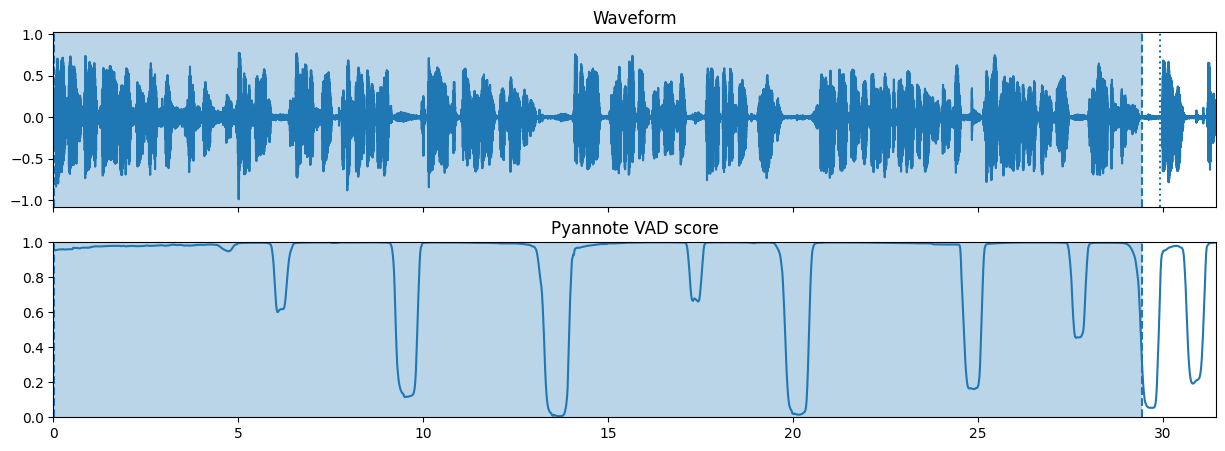

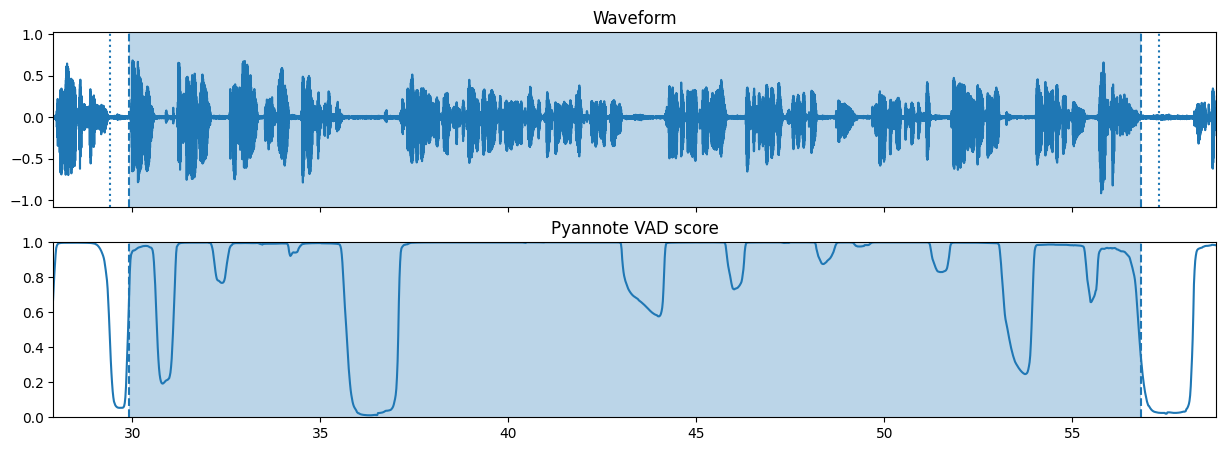

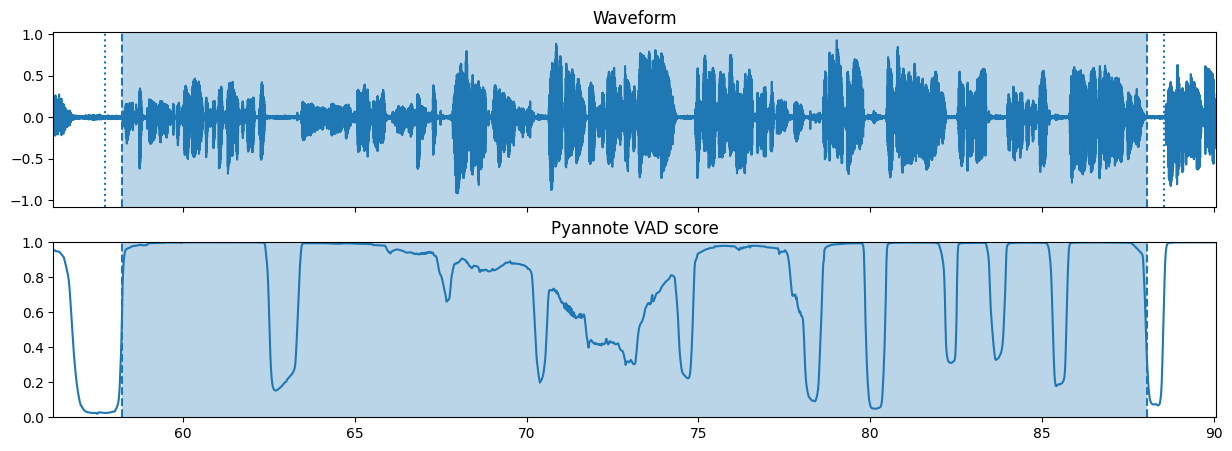

In [18]:
inspect_chunk(
    wav_path,
    vad_scores,
    chunks[0]
)

inspect_chunk(
    wav_path,
    vad_scores,
    chunks[1]
)

inspect_chunk(
    wav_path,
    vad_scores,
    chunks[2]
)

In [5]:
import numpy as np
import librosa

from whisperx.vads.pyannote import load_vad_model


# ============================================================
# CONFIG
# ============================================================

WAV_PATH = "/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav"

TEXTGRID_PATH = "vad.TextGrid"


# ============================================================
# LOAD PYANNOTE
# ============================================================

vad_pipeline = load_vad_model(
    device="cuda",
    token=os.environ["HF_TOKEN"]
)
wav_path = "/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav"
vad_scores = vad_pipeline("/vol/corpora/Rhapsodie/wav16k_corrected/Rhap-D2001.wav")

# ============================================================
# EXTRACT SPEECH SEGMENTS
# ============================================================

scores = vad_scores.data[:, 0]

frames = vad_scores.sliding_window

times = np.array(
    [frames[i].middle for i in range(len(scores))]
)

ONSET = 0.5
OFFSET = 0.363

speech_segments = []

is_active = scores[0] > ONSET

if is_active:
    start = times[0]

for t, score in zip(times[1:], scores[1:]):

    if is_active:

        if score < OFFSET:
            speech_segments.append((start, t))
            is_active = False

    else:

        if score > ONSET:
            start = t
            is_active = True

if is_active:
    speech_segments.append((start, times[-1]))


# ============================================================
# AUDIO DURATION
# ============================================================

audio, sr = librosa.load(WAV_PATH, sr=None)

audio_duration = len(audio) / sr


# ============================================================
# CREATE INTERVALS
# ============================================================

intervals = []

prev_end = 0.0

for start, end in speech_segments:

    if start > prev_end:

        intervals.append(
            (prev_end, start, "silence")
        )

    intervals.append(
        (start, end, "speech")
    )

    prev_end = end

if prev_end < audio_duration:

    intervals.append(
        (prev_end, audio_duration, "silence")
    )


# ============================================================
# WRITE TEXTGRID
# ============================================================

with open(TEXTGRID_PATH, "w") as f:

    f.write('File type = "ooTextFile"\n')
    f.write('Object class = "TextGrid"\n\n')

    f.write("xmin = 0\n")
    f.write(f"xmax = {audio_duration}\n")
    f.write("tiers? <exists>\n")
    f.write("size = 1\n")
    f.write("item []:\n")

    f.write("    item [1]:\n")
    f.write('        class = "IntervalTier"\n')
    f.write('        name = "VAD"\n')
    f.write("        xmin = 0\n")
    f.write(f"        xmax = {audio_duration}\n")
    f.write(f"        intervals: size = {len(intervals)}\n")

    for i, (xmin, xmax, label) in enumerate(intervals, start=1):

        f.write(f"        intervals [{i}]:\n")
        f.write(f"            xmin = {xmin}\n")
        f.write(f"            xmax = {xmax}\n")
        f.write(f'            text = "{label}"\n')

print(f"Saved TextGrid to {TEXTGRID_PATH}")

Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.5. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../../../../../../home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/whisperx/assets/pytorch_model.bin`


Saved TextGrid to vad.TextGrid
